In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
df = pd.read_csv("games.csv")

In [5]:
numeric_df = df.select_dtypes(include=np.number)

In [6]:
numeric_df.shape

(122611, 17)

In [7]:
import numpy as np

numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)

In [8]:
numeric_df = numeric_df.fillna(numeric_df.mean())

In [9]:
numeric_df.isnull().sum()

Estimated owners                   0
Peak CCU                           0
Required age                       0
Price                              0
DiscountDLC count                  0
Metacritic score                   0
User score                         0
Positive                           0
Negative                           0
Score rank                         0
Achievements                       0
Recommendations                    0
Average playtime forever           0
Average playtime two weeks         0
Median playtime forever            0
Median playtime two weeks          0
Movies                        122611
dtype: int64

In [10]:
numeric_df = numeric_df.dropna(axis=1, how='all')

In [11]:
numeric_df.isnull().sum()

Estimated owners              0
Peak CCU                      0
Required age                  0
Price                         0
DiscountDLC count             0
Metacritic score              0
User score                    0
Positive                      0
Negative                      0
Score rank                    0
Achievements                  0
Recommendations               0
Average playtime forever      0
Average playtime two weeks    0
Median playtime forever       0
Median playtime two weeks     0
dtype: int64

In [12]:
numeric_df = numeric_df.fillna(numeric_df.mean())

In [13]:
numeric_df.isnull().sum()

Estimated owners              0
Peak CCU                      0
Required age                  0
Price                         0
DiscountDLC count             0
Metacritic score              0
User score                    0
Positive                      0
Negative                      0
Score rank                    0
Achievements                  0
Recommendations               0
Average playtime forever      0
Average playtime two weeks    0
Median playtime forever       0
Median playtime two weeks     0
dtype: int64

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(numeric_df)

df_scaled = pd.DataFrame(df_scaled, columns=numeric_df.columns)

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df.head()

,PC1,PC2
0,-0.121535,-0.080620
1,-0.043021,-0.039922
2,-0.116312,-0.076647
3,-0.110421,-0.071505
4,-0.116970,-0.076547


In [16]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 122611 entries, 2539430 to 4141790
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       122610 non-null  object 
 1   Name                        122611 non-null  object 
 2   Release date                122611 non-null  object 
 3   Estimated owners            122611 non-null  int64  
 4   Peak CCU                    122611 non-null  int64  
 5   Required age                122611 non-null  float64
 6   Price                       122611 non-null  int64  
 7   DiscountDLC count           122611 non-null  int64  
 8   About the game              114162 non-null  object 
 9   Supported languages         122611 non-null  object 
 10  Full audio languages        122611 non-null  object 
 11  Reviews                     12070 non-null   object 
 12  Header image                122530 non-null  object 
 13  Website     

AppID                              1
Name                               0
Release date                       0
Estimated owners                   0
Peak CCU                           0
Required age                       0
Price                              0
DiscountDLC count                  0
About the game                  8449
Supported languages                0
Full audio languages               0
Reviews                       110541
Header image                      81
Website                        72935
Support url                    68469
Support email                  22263
Windows                            0
Mac                                0
Linux                              0
Metacritic score                   0
Metacritic url                118355
User score                         0
Positive                           0
Negative                           0
Score rank                    122571
Achievements                       0
Recommendations                    0
N

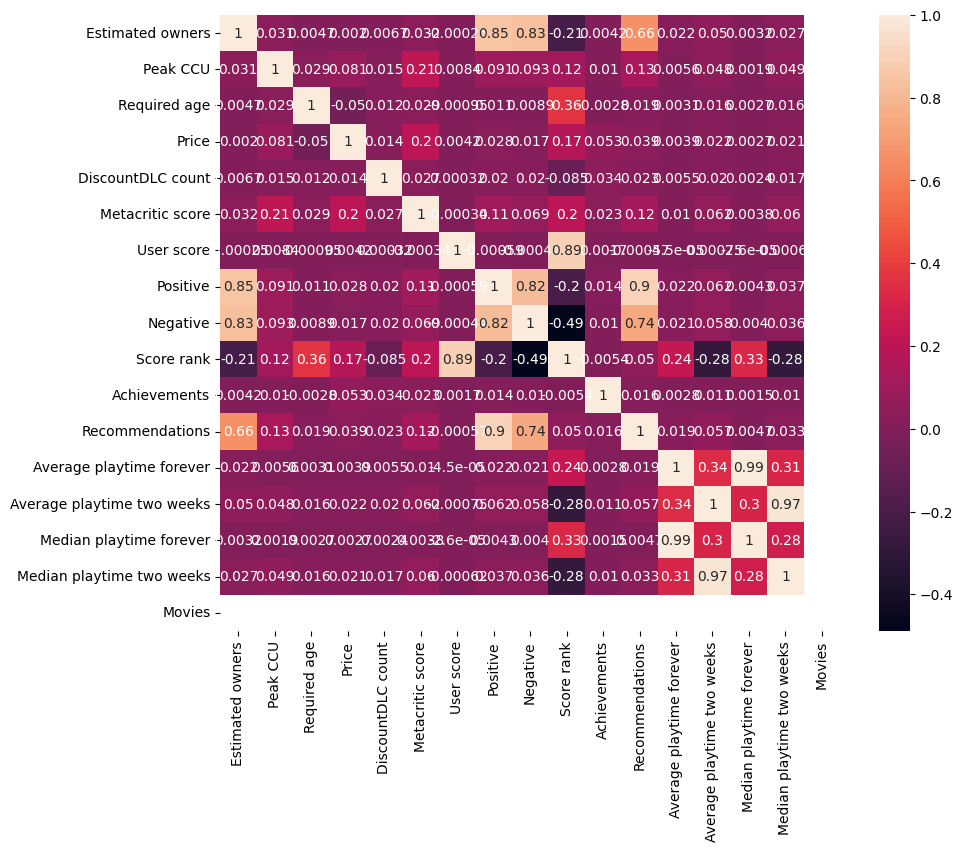

In [17]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

In [18]:
Q1 = numeric_df['Price'].quantile(0.25)
Q3 = numeric_df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

numeric_df = numeric_df[(numeric_df['Price'] >= lower) & (numeric_df['Price'] <= upper)]

In [19]:
pca = PCA()
pca.fit(df_scaled)

print(pca.explained_variance_ratio_)

[0.215818   0.16150508 0.08850314 0.08008682 0.07502694 0.0648498
 0.06398536 0.06017933 0.05528968 0.04992949 0.04630737 0.02259715
 0.0111893  0.00277579 0.00164141 0.00031534]
